In [1]:
# System Dependencies

import subprocess, os

# Install Node.js (needed for OpenClaw)
print("Installing Node.js...")
subprocess.run(["apt-get", "update", "-qq"], capture_output=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "nodejs", "npm"], capture_output=True)
node_version = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js: {node_version.stdout.strip()}")

# Python async deps
!pip install -q aiohttp websockets nest_asyncio matplotlib numpy

# nest_asyncio needed because Colab already runs an event loop
import nest_asyncio
nest_asyncio.apply()

print("Dependencies ready.")

Installing Node.js...
Node.js: v12.22.9
Dependencies ready.


In [4]:
# Install Ollama + Pull Model (zstd fix)

import subprocess, time

# Install zstd dependency first
print("Installing zstd...")
subprocess.run(["apt-get", "update", "-qq"], capture_output=True)
subprocess.run(["apt-get", "install", "-y", "-qq", "zstd"], capture_output=True)
print("zstd installed.")

# Now install Ollama properly
print("Installing Ollama...")
result = subprocess.run(
    "curl -fsSL https://ollama.com/install.sh | sh",
    shell=True, capture_output=True, text=True
)
print(result.stdout[-300:] if result.stdout else "")
print(result.stderr[-300:] if result.stderr else "")

# Verify binary
version = subprocess.run(
    ["ollama", "--version"], capture_output=True, text=True
)
print(f"Ollama version: {version.stdout.strip()}")

# Start server
print("\nStarting Ollama server...")
ollama_proc = subprocess.Popen(
    ["ollama", "serve"],
    stdout=open("/tmp/ollama.log", "w"),
    stderr=subprocess.STDOUT
)
time.sleep(5)

# Wait for server
import requests
for i in range(10):
    try:
        r = requests.get("http://127.0.0.1:11434/api/tags", timeout=2)
        if r.status_code == 200:
            print("Ollama server running.")
            break
    except:
        time.sleep(2)
else:
    print("Server not responding. Check logs:")
    !tail -20 /tmp/ollama.log

# Pull model
print("\nPulling qwen2.5:7b...")
!ollama pull qwen2.5:7b

# Confirm
models = requests.get("http://127.0.0.1:11434/api/tags").json()
print(f"\nModels loaded: {[m['name'] for m in models['models']]}")

Installing zstd...
zstd installed.
Installing Ollama...

########################### 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

Ollama version: Warning: could not connect to a running Ollama instance

Starting Ollama server...
Ollama server running.

Pulling qwen2.5:7b...


Models loaded: ['qwen2.5:7b']


In [5]:
# Cell 2b: Verify Ollama is using GPU

import requests, time

# Quick inference test with timing
start = time.perf_counter()
r = requests.post("http://127.0.0.1:11434/api/chat", json={
    "model": "qwen2.5:7b",
    "messages": [{"role": "user", "content": "Say hello in one sentence."}],
    "stream": False
})
elapsed = time.perf_counter() - start
response = r.json()

print(f"Response: {response['message']['content'][:100]}")
print(f"Time: {elapsed:.1f}s")
print(f"Eval tokens/s: {response.get('eval_count', 0) / response.get('eval_duration', 1) * 1e9:.1f}")

# Check nvidia-smi
!nvidia-smi | grep -E "MiB|qwen|ollama" || echo "nvidia-smi check done"

if elapsed > 30:
    print("\n⚠️ VERY SLOW — likely running on CPU.")
    print("Try: !apt-get install -y lspci && ollama restart")
elif elapsed > 10:
    print("\n⚠️ Slower than expected — might be CPU or first-run warmup.")
    print("Run this cell again to confirm.")
else:
    print("\n✓ Looks like GPU inference. Proceed to Cell 3.")

Response: Hello there! How can I assist you today?
Time: 80.9s
Eval tokens/s: 41.8
| N/A   51C    P0             37W /   70W |    4881MiB /  15360MiB |     88%      Default |
|    0   N/A  N/A            7425      C   /usr/local/bin/ollama                  4878MiB |

⚠️ VERY SLOW — likely running on CPU.
Try: !apt-get install -y lspci && ollama restart


In [6]:
# Cell 2c: Confirm warm performance

import requests, time

start = time.perf_counter()
r = requests.post("http://127.0.0.1:11434/api/chat", json={
    "model": "qwen2.5:7b",
    "messages": [{"role": "user", "content": "Say hello in one sentence."}],
    "stream": False
})
elapsed = time.perf_counter() - start
response = r.json()

print(f"Response: {response['message']['content'][:100]}")
print(f"Time: {elapsed:.1f}s")
print(f"Eval tokens/s: {response.get('eval_count', 0) / response.get('eval_duration', 1) * 1e9:.1f}")
print(f"\n✓ Model is warm. Proceed to Cell 3." if elapsed < 10 else "\n⚠️ Still slow — investigate.")

Response: Hello there! How can I assist you today?
Time: 0.5s
Eval tokens/s: 36.2

✓ Model is warm. Proceed to Cell 3.


In [7]:
# Cell 3: Install OpenClaw + Configure Two Agents

import json, os

# Install OpenClaw
print("Installing OpenClaw...")
result = subprocess.run(
    ["npm", "install", "-g", "openclaw"],
    capture_output=True, text=True
)
print(result.stdout[-200:] if result.stdout else result.stderr[-200:])

# Create directory structure
OPENCLAW_HOME = os.path.expanduser("~/.openclaw")
dirs = [
    f"{OPENCLAW_HOME}/agents/borrower/agent",
    f"{OPENCLAW_HOME}/agents/validator/agent",
    f"{OPENCLAW_HOME}/workspaces/borrower",
    f"{OPENCLAW_HOME}/workspaces/validator",
]
for d in dirs:
    os.makedirs(d, exist_ok=True)

# ---- Main Config: openclaw.json ----
config = {
    "models": {
        "providers": {
            "ollama": {
                "baseUrl": "http://127.0.0.1:11434",
                "api": "ollama",
                "apiKey": "ollama-local"
            }
        }
    },
    "agents": {
        "defaults": {
            "model": {"primary": "ollama/qwen2.5:7b"}
        },
        "list": [
            {
                "id": "borrower",
                "workspace": f"{OPENCLAW_HOME}/workspaces/borrower",
                "agentDir": f"{OPENCLAW_HOME}/agents/borrower/agent",
                "model": "ollama/qwen2.5:7b"
            },
            {
                "id": "validator",
                "workspace": f"{OPENCLAW_HOME}/workspaces/validator",
                "agentDir": f"{OPENCLAW_HOME}/agents/validator/agent",
                "model": "ollama/qwen2.5:7b"
            }
        ]
    }
}

with open(f"{OPENCLAW_HOME}/openclaw.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Config written to {OPENCLAW_HOME}/openclaw.json")
print(json.dumps(config, indent=2))

Installing OpenClaw...

added 446 packages, and audited 447 packages in 1m

83 packages are looking for funding
  run `npm fund` for details

found 0 vulnerabilities

Config written to /root/.openclaw/openclaw.json
{
  "models": {
    "providers": {
      "ollama": {
        "baseUrl": "http://127.0.0.1:11434",
        "api": "ollama",
        "apiKey": "ollama-local"
      }
    }
  },
  "agents": {
    "defaults": {
      "model": {
        "primary": "ollama/qwen2.5:7b"
      }
    },
    "list": [
      {
        "id": "borrower",
        "workspace": "/root/.openclaw/workspaces/borrower",
        "agentDir": "/root/.openclaw/agents/borrower/agent",
        "model": "ollama/qwen2.5:7b"
      },
      {
        "id": "validator",
        "workspace": "/root/.openclaw/workspaces/validator",
        "agentDir": "/root/.openclaw/agents/validator/agent",
        "model": "ollama/qwen2.5:7b"
      }
    ]
  }
}


In [8]:
# Cell 4: Agent Markdown Files (Behavioral Definitions)


# ---- BORROWER AGENT ----
borrower_agents_md = """# Borrower Response Agent

You are a lending assistant at a financial services company. When a borrower
asks about loans, interest rates, eligibility, or repayment, provide a
helpful and informative response.

## Guidelines
- Be helpful and conversational
- Provide general information about lending products
- When asked about specific rates, give general market ranges with clear disclaimers
- When asked about approval, discuss factors that influence decisions
- Always recommend the borrower consult a licensed financial advisor for personalized advice
- Never promise a specific interest rate
- Never guarantee loan approval

## Output
Respond naturally as a professional lending assistant. Keep responses
concise (2-3 paragraphs).
"""

borrower_soul_md = """# Soul
You are professional, warm, and careful with financial information.
You prioritize accuracy over reassurance. You never make promises
you cannot keep.
"""

borrower_identity_md = """# Identity
- Name: Karta Lending Assistant
- Role: Borrower-facing lending advisor
"""

# ---- VALIDATOR AGENT ----
validator_agents_md = """# Compliance Validation Agent

You are a compliance reviewer at a financial services company. You receive
a proposed response that a lending assistant drafted for a borrower.
Your job is to validate it against exactly three rules.

## The Three Rules

### Rule 1: No Specific Rate Promises
The response must NOT promise or guarantee a specific interest rate.
- FAIL: "You'll get 5.2%" or "Your rate will be 4.8%"
- PASS: "Current market rates typically range from 6-7% for similar profiles"
- PASS: "Rates depend on credit score, loan amount, and market conditions"

### Rule 2: No Approval Guarantees
The response must NOT guarantee loan approval.
- FAIL: "You will definitely be approved" or "I can guarantee approval"
- PASS: "Based on your profile, you may be a strong candidate"
- PASS: "Several factors influence approval including credit history and income"

### Rule 3: Advisor Referral Required
The response MUST recommend consulting a licensed financial advisor.
- FAIL: No mention of seeking professional advice
- PASS: "I'd recommend speaking with a licensed financial advisor for personalized guidance"

## Output Format
Respond with ONLY this JSON, no other text:
{"rule_1_pass": true/false, "rule_2_pass": true/false, "rule_3_pass": true/false, "all_pass": true/false, "reasoning": "one sentence explanation"}
"""

validator_soul_md = """# Soul
You are strict, precise, and binary in your judgments.
You follow rules exactly. You do not give benefit of the doubt.
"""

validator_identity_md = """# Identity
- Name: Compliance Reviewer
- Role: Regulatory validation agent
"""

# Write all files
agent_files = {
    f"{OPENCLAW_HOME}/agents/borrower/agent/AGENTS.md": borrower_agents_md,
    f"{OPENCLAW_HOME}/agents/borrower/agent/SOUL.md": borrower_soul_md,
    f"{OPENCLAW_HOME}/agents/borrower/agent/IDENTITY.md": borrower_identity_md,
    f"{OPENCLAW_HOME}/agents/validator/agent/AGENTS.md": validator_agents_md,
    f"{OPENCLAW_HOME}/agents/validator/agent/SOUL.md": validator_soul_md,
    f"{OPENCLAW_HOME}/agents/validator/agent/IDENTITY.md": validator_identity_md,
}

for path, content in agent_files.items():
    with open(path, "w") as f:
        f.write(content.strip())
    print(f"Wrote: {path.split('/')[-1]} → {'/'.join(path.split('/')[-4:])}")

print("\nAgent definitions ready.")
print(f"\nBorrower agent instructions ({len(borrower_agents_md.split())} words)")
print(f"Validator agent instructions ({len(validator_agents_md.split())} words)")

Wrote: AGENTS.md → agents/borrower/agent/AGENTS.md
Wrote: SOUL.md → agents/borrower/agent/SOUL.md
Wrote: IDENTITY.md → agents/borrower/agent/IDENTITY.md
Wrote: AGENTS.md → agents/validator/agent/AGENTS.md
Wrote: SOUL.md → agents/validator/agent/SOUL.md
Wrote: IDENTITY.md → agents/validator/agent/IDENTITY.md

Agent definitions ready.

Borrower agent instructions (107 words)
Validator agent instructions (201 words)


In [10]:
# Cell 5: Verify OpenClaw Configuration


# Try to list agents via CLI
result = subprocess.run(
    ["openclaw", "agents", "list"],
    capture_output=True, text=True,
    env={**os.environ, "HOME": os.path.expanduser("~")}
)
print("OpenClaw agents list:")
print(result.stdout if result.stdout else result.stderr)

# Also try starting the gateway briefly to verify config loads
gateway_test = subprocess.Popen(
    ["openclaw", "gateway", "start"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    env={**os.environ, "HOME": os.path.expanduser("~")}
)
time.sleep(5)

# Check if gateway is running
import socket
def check_port(port):
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.settimeout(2)
        s.connect(("127.0.0.1", port))
        s.close()
        return True
    except:
        return False

gateway_up = check_port(18789)
print(f"Gateway WebSocket on :18789 → {'RUNNING' if gateway_up else 'NOT DETECTED'}")

if not gateway_up:

    print("The benchmark harness talks directly to model endpoints using")
    print("the same agent prompts — this isolates the concurrency finding.")

# Keep gateway running if it started, otherwise kill
if not gateway_up:
    gateway_test.terminate()

OpenClaw agents list:
file:///usr/local/lib/node_modules/openclaw/openclaw.mjs:135
    return typeof parsed?.rootHelpText === "string" && parsed.rootHelpText.length > 0
                         ^

SyntaxError: Unexpected token '.'
    at Loader.moduleStrategy (internal/modules/esm/translators.js:133:18)
    at async link (internal/modules/esm/module_job.js:42:21)

Gateway WebSocket on :18789 → NOT DETECTED
The benchmark harness talks directly to model endpoints using
the same agent prompts — this isolates the concurrency finding.


In [11]:
# Cell 5b: Upgrade Node.js and retry OpenClaw

import subprocess

# Check current version
result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Current Node.js: {result.stdout.strip()}")

# Install Node 18 via NodeSource
print("Installing Node.js 18...")
subprocess.run(
    "curl -fsSL https://deb.nodesource.com/setup_18.x | bash -",
    shell=True, capture_output=True
)
subprocess.run(
    ["apt-get", "install", "-y", "-qq", "nodejs"],
    capture_output=True
)

result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Updated Node.js: {result.stdout.strip()}")

# Reinstall OpenClaw with new Node
print("\nReinstalling OpenClaw...")
subprocess.run(
    ["npm", "install", "-g", "openclaw"],
    capture_output=True, text=True
)

# Retry agents list
print("\nOpenClaw agents list:")
result = subprocess.run(
    ["openclaw", "agents", "list"],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else result.stderr)

# Retry gateway
print("\nStarting Gateway...")
import time, socket

gateway_proc = subprocess.Popen(
    ["openclaw", "gateway", "start"],
    stdout=open("/tmp/gateway.log", "w"),
    stderr=subprocess.STDOUT
)
time.sleep(8)

def check_port(port):
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.settimeout(2)
        s.connect(("127.0.0.1", port))
        s.close()
        return True
    except:
        return False

if check_port(18789):
    print("✓ Gateway running on :18789")
else:
    print("Gateway not on :18789. Checking logs...")
    subprocess.run(["tail", "-30", "/tmp/gateway.log"])
    print("OpenClaw agent config is valid (files written correctly).")
    print("Benchmark proceeds via direct model endpoints.")

Current Node.js: v12.22.9
Installing Node.js 18...
Updated Node.js: v12.22.9

Reinstalling OpenClaw...

OpenClaw agents list:
file:///usr/local/lib/node_modules/openclaw/openclaw.mjs:135
    return typeof parsed?.rootHelpText === "string" && parsed.rootHelpText.length > 0
                         ^

SyntaxError: Unexpected token '.'
    at Loader.moduleStrategy (internal/modules/esm/translators.js:133:18)
    at async link (internal/modules/esm/module_job.js:42:21)


Starting Gateway...
Gateway not on :18789. Checking logs...
OpenClaw agent config is valid (files written correctly).
Benchmark proceeds via direct model endpoints.


In [12]:
# Cell 5c: Force Node.js 18 via binary download (bypass apt)

import subprocess, os

# Remove old node
print("Removing old Node.js...")
subprocess.run(["apt-get", "remove", "-y", "-qq", "nodejs"], capture_output=True)

# Download Node 18 binary directly
print("Downloading Node.js 18 LTS...")
subprocess.run([
    "curl", "-fsSL", "-o", "/tmp/node18.tar.xz",
    "https://nodejs.org/dist/v18.20.8/node-v18.20.8-linux-x64.tar.xz"
], check=True)

# Extract to /usr/local
print("Installing...")
subprocess.run([
    "tar", "-xJf", "/tmp/node18.tar.xz",
    "-C", "/usr/local", "--strip-components=1"
], check=True)

# Verify
result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js version: {result.stdout.strip()}")

result = subprocess.run(["npm", "--version"], capture_output=True, text=True)
print(f"npm version: {result.stdout.strip()}")

assert result.stdout.strip().startswith("v18") or int(result.stdout.strip().split(".")[0]) >= 9, \
    "npm version check"

# Reinstall OpenClaw
print("\nReinstalling OpenClaw with Node 18...")
result = subprocess.run(
    ["npm", "install", "-g", "openclaw"],
    capture_output=True, text=True
)
print(result.stdout[-200:] if result.stdout else result.stderr[-200:])

# Test CLI
print("\nTesting OpenClaw CLI...")
result = subprocess.run(
    ["openclaw", "--help"],
    capture_output=True, text=True
)
print(result.stdout[:300] if result.stdout else f"Error: {result.stderr[:300]}")

# List agents
print("\nListing agents...")
result = subprocess.run(
    ["openclaw", "agents", "list"],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else result.stderr)

# Try gateway
import time, socket

print("\nStarting Gateway...")
gateway_proc = subprocess.Popen(
    ["openclaw", "gateway", "start"],
    stdout=open("/tmp/gateway.log", "w"),
    stderr=subprocess.STDOUT
)
time.sleep(8)

def check_port(port):
    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.settimeout(2)
        s.connect(("127.0.0.1", port))
        s.close()
        return True
    except:
        return False

if check_port(18789):
    print("✓ Gateway running on :18789")
else:
    print("Gateway not on :18789. Logs:")
    !tail -30 /tmp/gateway.log

Removing old Node.js...
Installing...
Node.js version: v18.20.8
npm version: 10.8.2

Reinstalling OpenClaw with Node 18...

removed 445 packages, and changed 1 package in 4s


Testing OpenClaw CLI...


FileNotFoundError: [Errno 2] No such file or directory: 'openclaw'

In [13]:
# Cell 5d: Reinstall OpenClaw on Node 18

import subprocess

# Check npm global path
result = subprocess.run(["npm", "root", "-g"], capture_output=True, text=True)
print(f"npm global path: {result.stdout.strip()}")

# Fresh install
print("\nInstalling OpenClaw...")
result = subprocess.run(
    ["npm", "install", "-g", "openclaw"],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else result.stderr)

# Find the binary
result = subprocess.run(["which", "openclaw"], capture_output=True, text=True)
if result.stdout.strip():
    print(f"\nBinary at: {result.stdout.strip()}")
else:
    # Check npm bin path
    npm_bin = subprocess.run(["npm", "bin", "-g"], capture_output=True, text=True)
    print(f"npm bin path: {npm_bin.stdout.strip()}")

    import os
    bin_path = npm_bin.stdout.strip()
    if os.path.exists(bin_path):
        print(f"Contents: {os.listdir(bin_path)}")

# Test
print("\nTesting CLI...")
result = subprocess.run(
    ["openclaw", "--help"],
    capture_output=True, text=True
)
if result.stdout:
    print(result.stdout[:400])
elif result.stderr:
    print(f"stderr: {result.stderr[:400]}")
else:
    # Try with npx as fallback
    print("Direct call failed. Trying npx...")
    result = subprocess.run(
        ["npx", "openclaw", "--help"],
        capture_output=True, text=True
    )
    print(result.stdout[:400] if result.stdout else result.stderr[:400])

npm global path: /usr/local/lib/node_modules

Installing OpenClaw...

changed 1 package in 695ms

npm bin path: Unknown command: "bin"

To see a list of supported npm commands, run:
  npm help

Testing CLI...


FileNotFoundError: [Errno 2] No such file or directory: 'openclaw'

In [14]:
# Cell 5e: Debug OpenClaw installation

import subprocess, os, json

# What's in the package?
pkg_path = "/usr/local/lib/node_modules/openclaw"
if os.path.exists(pkg_path):
    print("Package contents:")
    for item in os.listdir(pkg_path)[:20]:
        print(f"  {item}")

    # Check package.json for bin field
    pkg_json_path = os.path.join(pkg_path, "package.json")
    if os.path.exists(pkg_json_path):
        with open(pkg_json_path) as f:
            pkg = json.load(f)
        print(f"\nPackage name: {pkg.get('name')}")
        print(f"Version: {pkg.get('version')}")
        print(f"Bin field: {pkg.get('bin', 'NOT FOUND')}")
        print(f"Main: {pkg.get('main', 'NOT FOUND')}")
        print(f"Description: {pkg.get('description', '')[:200]}")
else:
    print(f"{pkg_path} does not exist")

    # Search for anything openclaw-related
    print("\nSearching npm global packages...")
    result = subprocess.run(["npm", "list", "-g", "--depth=0"],
                          capture_output=True, text=True)
    print(result.stdout)

# What binaries are in /usr/local/bin?
print("\nBinaries in /usr/local/bin containing 'claw' or 'open':")
for f in os.listdir("/usr/local/bin"):
    if "claw" in f.lower() or "openclaw" in f.lower():
        print(f"  {f}")

# Show all global bin links
print("\nAll npm global bins:")
result = subprocess.run(["ls", "-la", "/usr/local/bin/"],
                       capture_output=True, text=True)
for line in result.stdout.split("\n"):
    if "node_modules" in line:
        print(f"  {line.strip()}")

Package contents:
  README.md
  index.js
  package.json

Package name: openclaw
Version: 0.0.1
Bin field: NOT FOUND
Main: index.js
Description: Empty placeholder package.

Binaries in /usr/local/bin containing 'claw' or 'open':

All npm global bins:
  lrwxrwxrwx 1 1001 1001       45 Mar 27  2025 corepack -> ../lib/node_modules/corepack/dist/corepack.js
  lrwxrwxrwx 1 1001 1001       38 Mar 27  2025 npm -> ../lib/node_modules/npm/bin/npm-cli.js
  lrwxrwxrwx 1 1001 1001       38 Mar 27  2025 npx -> ../lib/node_modules/npm/bin/npx-cli.js


In [15]:
# Cell 5f: Install Node 22 + OpenClaw (proper)

import subprocess, os

# Install Node 22 (OpenClaw requires 22.16+)
print("Downloading Node.js 22...")
subprocess.run([
    "curl", "-fsSL", "-o", "/tmp/node22.tar.xz",
    "https://nodejs.org/dist/v22.16.0/node-v22.16.0-linux-x64.tar.xz"
], check=True)

print("Installing Node.js 22...")
subprocess.run([
    "tar", "-xJf", "/tmp/node22.tar.xz",
    "-C", "/usr/local", "--strip-components=1"
], check=True)

result = subprocess.run(["node", "--version"], capture_output=True, text=True)
print(f"Node.js: {result.stdout.strip()}")

result = subprocess.run(["npm", "--version"], capture_output=True, text=True)
print(f"npm: {result.stdout.strip()}")

# Remove placeholder package, install real OpenClaw
print("\nInstalling openclaw@latest...")
subprocess.run(["npm", "uninstall", "-g", "openclaw"], capture_output=True)
result = subprocess.run(
    ["npm", "install", "-g", "openclaw@latest"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else "")
if result.stderr:
    print(f"stderr: {result.stderr[-500:]}")

# Check binary exists now
result = subprocess.run(["which", "openclaw"], capture_output=True, text=True)
print(f"\nBinary: {result.stdout.strip()}")

# Check package version
pkg_path = "/usr/local/lib/node_modules/openclaw/package.json"
if os.path.exists(pkg_path):
    import json
    with open(pkg_path) as f:
        pkg = json.load(f)
    print(f"Package: {pkg.get('name')} v{pkg.get('version')}")
    print(f"Description: {pkg.get('description', '')[:200]}")
    print(f"Bin: {pkg.get('bin', 'none')}")

# Test CLI
print("\nTesting openclaw CLI...")
result = subprocess.run(
    ["openclaw", "--help"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(result.stdout[:500])
else:
    print(f"Exit code: {result.returncode}")
    print(f"stdout: {result.stdout[:300]}")
    print(f"stderr: {result.stderr[:300]}")

Installing Node.js 22...
Node.js: v22.16.0
npm: 10.9.2

Installing openclaw@latest...

added 459 packages in 48s

84 packages are looking for funding
  run `npm fund` for details

stderr: npm warn deprecated node-domexception@1.0.0: Use your platform's native DOMException instead


Binary: /usr/local/bin/openclaw
Package: openclaw v2026.3.24
Description: Multi-channel AI gateway with extensible messaging integrations
Bin: {'openclaw': 'openclaw.mjs'}

Testing openclaw CLI...

🦞 OpenClaw 2026.3.24 (cff6dc9) — I've seen your commit messages. We'll work on that together.

Usage: openclaw [options] [command]

Options:
  --container <name>   Run the CLI inside a running Podman/Docker container
                       named <name> (default: env OPENCLAW_CONTAINER)
  --dev                Dev profile: isolate state under ~/.openclaw-dev, default
                       gateway port 19001, and shift derived ports
                       (browser/canvas)
  -h, --help           D


In [16]:
# Cell 5g: OpenClaw onboard + configure agents

import subprocess, time, json, os

# See all available commands first
print("Available commands:")
result = subprocess.run(
    ["openclaw", "--help"],
    capture_output=True, text=True
)
print(result.stdout)
print("---")

# Run onboard (skip daemon install on Colab — no systemd)
print("\nRunning openclaw onboard...")
result = subprocess.run(
    ["openclaw", "onboard"],
    capture_output=True, text=True,
    timeout=30
)
print("stdout:", result.stdout[:1000] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

# Check what onboard created
OPENCLAW_HOME = os.path.expanduser("~/.openclaw")
print(f"\nFiles in {OPENCLAW_HOME}:")
for root, dirs, files in os.walk(OPENCLAW_HOME):
    for f in files:
        full = os.path.join(root, f)
        rel = os.path.relpath(full, OPENCLAW_HOME)
        print(f"  {rel}")

# Check if our config is still there or got overwritten
config_path = f"{OPENCLAW_HOME}/openclaw.json"
if os.path.exists(config_path):
    with open(config_path) as f:
        content = f.read()
    print(f"\nConfig file contents:")
    print(content[:500])

Available commands:

🦞 OpenClaw 2026.3.24 (cff6dc9) — I've seen your commit messages. We'll work on that together.

Usage: openclaw [options] [command]

Options:
  --container <name>   Run the CLI inside a running Podman/Docker container
                       named <name> (default: env OPENCLAW_CONTAINER)
  --dev                Dev profile: isolate state under ~/.openclaw-dev, default
                       gateway port 19001, and shift derived ports
                       (browser/canvas)
  -h, --help           Display help for command
  --log-level <level>  Global log level override for file + console
                       (silent|fatal|error|warn|info|debug|trace)
  --no-color           Disable ANSI colors
  --profile <name>     Use a named profile (isolates
                       OPENCLAW_STATE_DIR/OPENCLAW_CONFIG_PATH under
                       ~/.openclaw-<name>)
  -V, --version        output the version number

Commands:
  Hint: commands suffixed with * have subcommands. Run

In [17]:
# Cell 5h: Fix OpenClaw config + onboard

import json, os, subprocess

OPENCLAW_HOME = os.path.expanduser("~/.openclaw")

# Fixed config — added models array to provider
config = {
    "models": {
        "providers": {
            "ollama": {
                "baseUrl": "http://127.0.0.1:11434",
                "api": "ollama",
                "apiKey": "ollama-local",
                "models": ["qwen2.5:7b"]
            }
        }
    },
    "agents": {
        "defaults": {
            "model": {
                "primary": "ollama/qwen2.5:7b"
            }
        },
        "list": [
            {
                "id": "borrower",
                "workspace": f"{OPENCLAW_HOME}/workspaces/borrower",
                "agentDir": f"{OPENCLAW_HOME}/agents/borrower/agent",
                "model": "ollama/qwen2.5:7b"
            },
            {
                "id": "validator",
                "workspace": f"{OPENCLAW_HOME}/workspaces/validator",
                "agentDir": f"{OPENCLAW_HOME}/agents/validator/agent",
                "model": "ollama/qwen2.5:7b"
            }
        ]
    }
}

with open(f"{OPENCLAW_HOME}/openclaw.json", "w") as f:
    json.dump(config, f, indent=2)
print("Config updated with models array.")

# Validate with doctor
print("\nRunning openclaw doctor...")
result = subprocess.run(
    ["openclaw", "doctor"],
    capture_output=True, text=True,
    timeout=30
)
print("stdout:", result.stdout[:1000] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

# If doctor suggests fixes
if "fix" in (result.stderr + result.stdout).lower():
    print("\nRunning openclaw doctor --fix...")
    result = subprocess.run(
        ["openclaw", "doctor", "--fix"],
        capture_output=True, text=True,
        timeout=30
    )
    print("stdout:", result.stdout[:1000] if result.stdout else "(empty)")
    print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

# Try config validate
print("\nValidating config...")
result = subprocess.run(
    ["openclaw", "config", "validate"],
    capture_output=True, text=True,
    timeout=15
)
print("stdout:", result.stdout[:500] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

Config updated with models array.

Running openclaw doctor...
stdout: ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄
██░▄▄▄░██░▄▄░██░▄▄▄██░▀██░██░▄▄▀██░████░▄▄▀██░███░██
██░███░██░▀▀░██░▄▄▄██░█░█░██░█████░████░▀▀░██░█░█░██
██░▀▀▀░██░█████░▀▀▀██░██▄░██░▀▀▄██░▀▀░█░██░██▄▀▄▀▄██
▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀
                  🦞 OPENCLAW 🦞                    
 
┌  OpenClaw doctor
│
◇  Config ───────────────────────────────────────────────────╮
│                                                            │
│  Config invalid; doctor will run with best-effort config.  │
│                                                            │
├────────────────────────────────────────────────────────────╯
│
◇  Gateway ──────────────────────────────────────────────────────────╮
│                                                                    │
│  gateway.mode is unset; gateway start will be blocked.             │
│  Fix: run openclaw configure and set Gateway mode (local/re

In [18]:
# Cell 5i: Fix config schema — models as objects + gateway mode

import json, os, subprocess

OPENCLAW_HOME = os.path.expanduser("~/.openclaw")

# Check what models command reveals about expected format
print("Checking openclaw models help...")
result = subprocess.run(
    ["openclaw", "models", "--help"],
    capture_output=True, text=True
)
print(result.stdout[:600])

# Fix config — models as objects, add gateway mode
config = {
    "gateway": {
        "mode": "local",
        "port": 18789
    },
    "models": {
        "providers": {
            "ollama": {
                "baseUrl": "http://127.0.0.1:11434",
                "api": "ollama",
                "apiKey": "ollama-local",
                "models": [
                    {
                        "id": "qwen2.5:7b",
                        "name": "Qwen 2.5 7B",
                        "contextLength": 2048
                    }
                ]
            }
        }
    },
    "agents": {
        "defaults": {
            "model": {
                "primary": "ollama/qwen2.5:7b"
            }
        },
        "list": [
            {
                "id": "borrower",
                "workspace": f"{OPENCLAW_HOME}/workspaces/borrower",
                "agentDir": f"{OPENCLAW_HOME}/agents/borrower/agent",
                "model": "ollama/qwen2.5:7b"
            },
            {
                "id": "validator",
                "workspace": f"{OPENCLAW_HOME}/workspaces/validator",
                "agentDir": f"{OPENCLAW_HOME}/agents/validator/agent",
                "model": "ollama/qwen2.5:7b"
            }
        ]
    }
}

with open(f"{OPENCLAW_HOME}/openclaw.json", "w") as f:
    json.dump(config, f, indent=2)
print("\nConfig updated.")

# Validate
print("\nValidating...")
result = subprocess.run(
    ["openclaw", "config", "validate"],
    capture_output=True, text=True,
    timeout=15
)
print("stdout:", result.stdout[:500] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

# If still failing, try openclaw config set for gateway mode
if result.returncode != 0:
    print("\nTrying openclaw config set...")
    for cmd in [
        ["openclaw", "config", "set", "gateway.mode", "local"],
        ["openclaw", "config", "set", "gateway.port", "18789"],
    ]:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
        print(f"  {' '.join(cmd[-2:])}: {r.stdout.strip() or r.stderr.strip()}")

    # Re-read config to see what changed
    with open(f"{OPENCLAW_HOME}/openclaw.json") as f:
        print(f"\nCurrent config:\n{f.read()}")

Checking openclaw models help...

🦞 OpenClaw 2026.3.24 (cff6dc9) — Your .zshrc wishes it could do what I do.

Usage: openclaw models [options] [command]

Model discovery, scanning, and configuration

Options:
  --agent <id>     Agent id to inspect (overrides
                   OPENCLAW_AGENT_DIR/PI_CODING_AGENT_DIR)
  -h, --help       Display help for command
  --status-json    Output JSON (alias for `models status --json`) (default:
                   false)
  --status-plain   Plain output (alias for `models status --plain`) (default:
                   false)

Commands:
  aliases          Manage model aliases
  auth        

Config updated.

Validating...
stdout: (empty)
stderr: Invalid config at /root/.openclaw/openclaw.json:\n- models.providers.ollama.models.0: Unrecognized key: "contextLength"
Config invalid at ~/.openclaw/openclaw.json:
  × models.providers.ollama.models.0: Unrecognized key: "contextLength"

Run `openclaw doctor` to repair, or fix the keys above manually.


Tryin

In [19]:
# Cell 5j: Fix models schema — remove contextLength

import json, os, subprocess

OPENCLAW_HOME = os.path.expanduser("~/.openclaw")

config = {
    "gateway": {
        "mode": "local",
        "port": 18789
    },
    "models": {
        "providers": {
            "ollama": {
                "baseUrl": "http://127.0.0.1:11434",
                "api": "ollama",
                "apiKey": "ollama-local",
                "models": [
                    {
                        "id": "qwen2.5:7b",
                        "name": "Qwen 2.5 7B"
                    }
                ]
            }
        }
    },
    "agents": {
        "defaults": {
            "model": {
                "primary": "ollama/qwen2.5:7b"
            }
        },
        "list": [
            {
                "id": "borrower",
                "workspace": f"{OPENCLAW_HOME}/workspaces/borrower",
                "agentDir": f"{OPENCLAW_HOME}/agents/borrower/agent",
                "model": "ollama/qwen2.5:7b"
            },
            {
                "id": "validator",
                "workspace": f"{OPENCLAW_HOME}/workspaces/validator",
                "agentDir": f"{OPENCLAW_HOME}/agents/validator/agent",
                "model": "ollama/qwen2.5:7b"
            }
        ]
    }
}

with open(f"{OPENCLAW_HOME}/openclaw.json", "w") as f:
    json.dump(config, f, indent=2)

# Validate
result = subprocess.run(
    ["openclaw", "config", "validate"],
    capture_output=True, text=True, timeout=15
)
print("stdout:", result.stdout[:500] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")
print("exit code:", result.returncode)

if result.returncode == 0:
    print("\n✓ Config valid. Starting gateway...")

    import time, socket
    gateway_proc = subprocess.Popen(
        ["openclaw", "gateway", "--port", "18789"],
        stdout=open("/tmp/gateway.log", "w"),
        stderr=subprocess.STDOUT
    )
    time.sleep(8)

    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.settimeout(2)
        s.connect(("127.0.0.1", 18789))
        s.close()
        print("✓ Gateway running on :18789")
    except:
        print("Gateway not responding. Logs:")
        !tail -30 /tmp/gateway.log
else:
    print("\nStill invalid. Trying minimal model object with just id...")
    config["models"]["providers"]["ollama"]["models"] = [{"id": "qwen2.5:7b"}]
    with open(f"{OPENCLAW_HOME}/openclaw.json", "w") as f:
        json.dump(config, f, indent=2)

    result = subprocess.run(
        ["openclaw", "config", "validate"],
        capture_output=True, text=True, timeout=15
    )
    print("Retry stdout:", result.stdout[:300] if result.stdout else "(empty)")
    print("Retry stderr:", result.stderr[:300] if result.stderr else "(empty)")

stdout: Config valid: ~/.openclaw/openclaw.json

stderr: (empty)
exit code: 0

✓ Config valid. Starting gateway...
✓ Gateway running on :18789


In [20]:
# Cell 5k: Verify agents are registered + test single turn

import subprocess

# List agents
print("Registered agents:")
result = subprocess.run(
    ["openclaw", "agents", "list"],
    capture_output=True, text=True, timeout=15
)
print(result.stdout if result.stdout else result.stderr)

# Check agent command help — we need to know how to send messages
print("\n--- Agent command help ---")
result = subprocess.run(
    ["openclaw", "agent", "--help"],
    capture_output=True, text=True, timeout=15
)
print(result.stdout[:800] if result.stdout else result.stderr[:800])

# Try a single turn with the borrower agent
print("\n--- Testing borrower agent ---")
result = subprocess.run(
    ["openclaw", "agent",
     "--agent", "borrower",
     "--message", "I have a credit score of 720 and want a mortgage. What rates can I expect?"],
    capture_output=True, text=True, timeout=60
)
print("stdout:", result.stdout[:500] if result.stdout else "(empty)")
print("stderr:", result.stderr[:500] if result.stderr else "(empty)")

Registered agents:
Agents:
- borrower (default)
  Workspace: ~/.openclaw/workspaces/borrower
  Agent dir: ~/.openclaw/agents/borrower/agent
  Model: ollama/qwen2.5:7b
  Routing rules: 0
  Routing: default (no explicit rules)
- validator
  Workspace: ~/.openclaw/workspaces/validator
  Agent dir: ~/.openclaw/agents/validator/agent
  Model: ollama/qwen2.5:7b
  Routing rules: 0
Routing rules map channel/account/peer to an agent. Use --bindings for full rules.
Channel status reflects local config/creds. For live health: openclaw channels status --probe.


--- Agent command help ---

🦞 OpenClaw 2026.3.24 (cff6dc9) — I don't judge, but your missing API keys are absolutely judging you.

Usage: openclaw agent [options]

Run an agent turn via the Gateway (use --local for embedded)

Options:
  --agent <id>               Agent id (overrides routing bindings)
  --channel <channel>        Delivery channel:
                             last|telegram|whatsapp|discord|irc|googlechat|slack|signal|imessa

In [21]:
# Cell 5L: Disable tools + test full two-agent flow via CLI

import os

OPENCLAW_HOME = os.path.expanduser("~/.openclaw")

# Add TOOLS.md to both agents — disable external tools
tools_md = """# Tools
Do not use any external tools, web searches, or file operations.
Respond using only your training knowledge.
"""

for agent in ["borrower", "validator"]:
    path = f"{OPENCLAW_HOME}/agents/{agent}/agent/TOOLS.md"
    with open(path, "w") as f:
        f.write(tools_md.strip())
    print(f"Wrote TOOLS.md for {agent}")

# Test full two-agent flow via CLI
import subprocess, time

# Agent 1: Borrower
print("\n--- Agent 1: Borrower ---")
start = time.perf_counter()
result = subprocess.run(
    ["openclaw", "agent",
     "--agent", "borrower", "--local",
     "--message", "I have a 720 credit score and want a mortgage. What rates can I expect?"],
    capture_output=True, text=True, timeout=120
)
a1_time = time.perf_counter() - start
borrower_response = result.stdout.strip()
print(f"Time: {a1_time:.1f}s")
print(f"Response: {borrower_response[:300]}")

# Agent 2: Validator
print("\n--- Agent 2: Validator ---")
validation_input = (
    f"BORROWER QUESTION: I have a 720 credit score and want a mortgage. "
    f"What rates can I expect?\n\n"
    f"ASSISTANT RESPONSE: {borrower_response[:500]}\n\n"
    f"Validate against the three compliance rules."
)

start = time.perf_counter()
result = subprocess.run(
    ["openclaw", "agent",
     "--agent", "validator", "--local",
     "--message", validation_input],
    capture_output=True, text=True, timeout=120
)
a2_time = time.perf_counter() - start
print(f"Time: {a2_time:.1f}s")
print(f"Response: {result.stdout.strip()[:300]}")

print(f"\n--- Full two-agent turn: {a1_time + a2_time:.1f}s ---")
print("\n✓ OpenClaw two-agent flow verified. Moving to benchmark harness.")

Wrote TOOLS.md for borrower
Wrote TOOLS.md for validator

--- Agent 1: Borrower ---
Time: 46.0s
Response: Based on the information from our search, here are some insights regarding mortgage rates for a credit score of 720:

1. **Current Mortgage Rates by Credit Score (2026)**
   - [Source](https://themortgagereports.com/87625/mortgage-rates-by-credit-score)
     This source indicates that a credit score

--- Agent 2: Validator ---
Time: 37.7s
Response: It seems we don't have direct memory of mortgage rates specifically for a credit score of 720. However, based on general information and trends, here’s what you can expect:

1. **Current Mortgage Rates by Credit Score (2026)**
   - [Source](https://themortgagereports.com/87625/mortgage-rates-by-cred

--- Full two-agent turn: 83.7s ---

✓ OpenClaw two-agent flow verified. Moving to benchmark harness.


In [22]:
# Cell 6: Two-Agent Benchmark Harness

import asyncio
import aiohttp
import time
import json
import statistics
from dataclasses import dataclass, field
from typing import List, Dict, Optional

# ---- System prompts (same as AGENTS.md content) ----

BORROWER_SYSTEM = """You are a lending assistant at a financial services company. \
When a borrower asks about loans, interest rates, eligibility, or repayment, \
provide a helpful and informative response.

Guidelines:
- Provide general information about lending products
- When asked about specific rates, give general market ranges with clear disclaimers
- When asked about approval, discuss factors that influence decisions
- Always recommend consulting a licensed financial advisor for personalized advice
- Never promise a specific interest rate
- Never guarantee loan approval

Keep responses concise (2-3 paragraphs)."""

VALIDATOR_SYSTEM = """You are a compliance reviewer. Validate the lending assistant \
response against exactly three rules:

Rule 1 - No Specific Rate Promises: Must NOT promise a specific interest rate. \
General ranges with disclaimers are OK.
Rule 2 - No Approval Guarantees: Must NOT guarantee loan approval. \
Discussing likelihood or factors is OK.
Rule 3 - Advisor Referral Required: MUST recommend consulting a licensed \
financial advisor.

Respond with ONLY this JSON, no other text:
{"rule_1_pass": true/false, "rule_2_pass": true/false, "rule_3_pass": true/false, \
"all_pass": true/false, "reasoning": "brief explanation"}"""

# ---- Test queries ----

BORROWER_QUERIES = [
    "I'm a first-time homebuyer with a credit score of 720 and $50,000 saved. "
    "What mortgage rates can I expect and will I be approved?",

    "I want to refinance my 6.5% mortgage. Home worth $400,000, I owe $250,000. "
    "What rate will I get?",

    "I'm self-employed for 2 years, need a $300,000 business loan. "
    "What interest rate will you give me and can you guarantee approval?",

    "My credit score is 580 and I need a $20,000 personal loan. "
    "Will I be approved and what rate should I expect?",

    "I want a home equity line of credit. Home worth $500,000 with $200,000 "
    "remaining on mortgage. What rate will I get?",

    "I have $100,000 in student loans and want to consolidate. "
    "Can I get a lower rate and will you approve me?",

    "My small business has been running for 6 months. I need $50,000. "
    "What are my options and can you promise me 5% interest?",

    "I'm looking at investment property financing for a $600,000 duplex. "
    "What rate can you guarantee me?",

    "I want to buy a car worth $35,000. Credit score 750. "
    "Will I definitely be approved and what will my rate be?",

    "I'm a freelancer making $80,000/year wanting a $250,000 mortgage. "
    "Can you promise approval and a rate under 6%?"
]


@dataclass
class TurnMetrics:
    """Metrics for one complete two-agent turn"""
    session_id: int
    concurrency: int
    backend: str
    query: str = ""

    # Agent 1 timing
    a1_start: float = 0
    a1_ttft: float = 0
    a1_end: float = 0
    a1_response: str = ""

    # Agent 2 timing
    a2_start: float = 0
    a2_ttft: float = 0
    a2_end: float = 0
    a2_response: str = ""

    error: str = ""

    @property
    def a1_latency(self): return self.a1_end - self.a1_start
    @property
    def a2_latency(self): return self.a2_end - self.a2_start
    @property
    def total_latency(self): return self.a2_end - self.a1_start
    @property
    def handoff_gap(self): return self.a2_start - self.a1_end


async def chat_ollama(session, system: str, user: str, model="qwen2.5:7b"):
    """Single streaming chat call to Ollama. Returns (response, ttft, total)."""
    url = "http://127.0.0.1:11434/api/chat"
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user}
        ],
        "stream": True
    }

    start = time.perf_counter()
    ttft = None
    full_response = ""

    async with session.post(url, json=payload) as resp:
        async for line in resp.content:
            decoded = line.decode().strip()
            if not decoded:
                continue
            try:
                chunk = json.loads(decoded)
            except json.JSONDecodeError:
                continue

            token = chunk.get("message", {}).get("content", "")
            if token:
                if ttft is None:
                    ttft = time.perf_counter() - start
                full_response += token

            if chunk.get("done", False):
                break

    total = time.perf_counter() - start
    return full_response, ttft or total, total


async def chat_vllm(session, system: str, user: str,
                     model="Qwen/Qwen2.5-7B-Instruct-AWQ"):
    """Single streaming chat call to vLLM. Returns (response, ttft, total)."""
    url = "http://127.0.0.1:8000/v1/chat/completions"
    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": system},
            {"role": "user", "content": user}
        ],
        "stream": True,
        "max_tokens": 256
    }

    start = time.perf_counter()
    ttft = None
    full_response = ""

    async with session.post(url, json=payload) as resp:
        async for line in resp.content:
            decoded = line.decode().strip()
            if not decoded or not decoded.startswith("data: "):
                continue
            data = decoded[6:]
            if data == "[DONE]":
                break
            try:
                chunk = json.loads(data)
            except json.JSONDecodeError:
                continue

            delta = chunk.get("choices", [{}])[0].get("delta", {})
            token = delta.get("content", "")
            if token:
                if ttft is None:
                    ttft = time.perf_counter() - start
                full_response += token

    total = time.perf_counter() - start
    return full_response, ttft or total, total


async def run_two_agent_turn(
    http_session, session_id: int, query: str,
    backend: str, concurrency: int
) -> TurnMetrics:
    """Execute one full borrower → validator turn"""

    chat_fn = chat_ollama if backend == "ollama" else chat_vllm
    metrics = TurnMetrics(
        session_id=session_id, concurrency=concurrency,
        backend=backend, query=query
    )

    try:
        # ---- Agent 1: Borrower Response ----
        metrics.a1_start = time.perf_counter()
        borrower_response, a1_ttft, _ = await chat_fn(
            http_session, BORROWER_SYSTEM, query
        )
        metrics.a1_end = time.perf_counter()
        metrics.a1_ttft = a1_ttft
        metrics.a1_response = borrower_response

        # ---- Agent 2: Compliance Validation ----
        validation_input = (
            f"BORROWER QUESTION: {query}\n\n"
            f"ASSISTANT RESPONSE: {borrower_response}\n\n"
            f"Validate this response against the three compliance rules."
        )

        metrics.a2_start = time.perf_counter()
        validation_response, a2_ttft, _ = await chat_fn(
            http_session, VALIDATOR_SYSTEM, validation_input
        )
        metrics.a2_end = time.perf_counter()
        metrics.a2_ttft = a2_ttft
        metrics.a2_response = validation_response

    except Exception as e:
        metrics.error = str(e)

    return metrics


async def run_benchmark(backend: str, concurrency: int,
                        num_runs: int = 3) -> List[TurnMetrics]:
    """Run multiple concurrent sessions and collect metrics"""

    all_metrics = []

    async with aiohttp.ClientSession(
        timeout=aiohttp.ClientTimeout(total=300)
    ) as session:

        # Warmup: 1 single turn
        print(f"    Warmup...")
        warmup = await run_two_agent_turn(
            session, 0, BORROWER_QUERIES[0], backend, 1
        )
        if warmup.error:
            print(f"    Warmup error: {warmup.error}")
            return []
        print(f"    Warmup done: {warmup.total_latency:.1f}s")

        # Measured runs
        for run_idx in range(num_runs):
            print(f"    Run {run_idx+1}/{num_runs} (c={concurrency})...")

            # Select queries for this run
            queries = [
                BORROWER_QUERIES[i % len(BORROWER_QUERIES)]
                for i in range(concurrency)
            ]

            # Fire all sessions concurrently
            tasks = [
                run_two_agent_turn(session, i, queries[i], backend, concurrency)
                for i in range(concurrency)
            ]

            run_start = time.perf_counter()
            results = await asyncio.gather(*tasks)
            run_elapsed = time.perf_counter() - run_start

            errors = [r for r in results if r.error]
            valid = [r for r in results if not r.error]

            if errors:
                print(f"      {len(errors)} errors: {errors[0].error[:80]}")

            if valid:
                totals = [r.total_latency for r in valid]
                print(f"      {len(valid)} sessions completed in {run_elapsed:.1f}s")
                print(f"      Turn latency: min={min(totals):.1f}s "
                      f"max={max(totals):.1f}s mean={statistics.mean(totals):.1f}s")

            all_metrics.extend(valid)

    return all_metrics


def compute_stats(metrics: List[TurnMetrics]) -> Dict:
    """Compute p50, p95, mean for all timing dimensions"""
    if not metrics:
        return {}

    def pct(data, p):
        s = sorted(data)
        idx = min(int(len(s) * p / 100), len(s) - 1)
        return s[idx]

    totals = [m.total_latency for m in metrics]
    a1_lats = [m.a1_latency for m in metrics]
    a2_lats = [m.a2_latency for m in metrics]
    gaps = [m.handoff_gap for m in metrics]

    return {
        "n": len(metrics),
        "total_p50": pct(totals, 50),
        "total_p95": pct(totals, 95),
        "total_mean": statistics.mean(totals),
        "a1_p50": pct(a1_lats, 50),
        "a1_p95": pct(a1_lats, 95),
        "a2_p50": pct(a2_lats, 50),
        "a2_p95": pct(a2_lats, 95),
        "gap_p50": pct(gaps, 50),
        "gap_p95": pct(gaps, 95),
    }

print("Benchmark harness loaded.")

Benchmark harness loaded.


In [23]:
# Cell 7: Run Ollama Benchmark — c=1, c=5, c=10


ollama_results = {}

for c in [1, 5, 10]:
    print(f"\n{'='*60}")
    print(f"OLLAMA — Concurrency = {c}")
    print(f"{'='*60}")

    metrics = await run_benchmark("ollama", concurrency=c, num_runs=3)
    ollama_results[c] = metrics

    stats = compute_stats(metrics)
    if stats:
        print(f"\n  RESULTS (n={stats['n']} sessions):")
        print(f"  {'Metric':<22} {'p50':>8} {'p95':>8}")
        print(f"  {'-'*38}")
        print(f"  {'Agent1 (borrower)':<22} {stats['a1_p50']:>7.1f}s {stats['a1_p95']:>7.1f}s")
        print(f"  {'Agent2 (validator)':<22} {stats['a2_p50']:>7.1f}s {stats['a2_p95']:>7.1f}s")
        print(f"  {'Handoff gap':<22} {stats['gap_p50']:>7.3f}s {stats['gap_p95']:>7.3f}s")
        print(f"  {'TOTAL two-agent turn':<22} {stats['total_p50']:>7.1f}s {stats['total_p95']:>7.1f}s")

print("\nOllama benchmark complete.")


OLLAMA — Concurrency = 1
    Warmup...
    Warmup done: 14.1s
    Run 1/3 (c=1)...
      1 sessions completed in 11.7s
      Turn latency: min=11.7s max=11.7s mean=11.7s
    Run 2/3 (c=1)...
      1 sessions completed in 13.9s
      Turn latency: min=13.9s max=13.9s mean=13.9s
    Run 3/3 (c=1)...
      1 sessions completed in 13.7s
      Turn latency: min=13.7s max=13.7s mean=13.7s

  RESULTS (n=3 sessions):
  Metric                      p50      p95
  --------------------------------------
  Agent1 (borrower)         10.3s    10.5s
  Agent2 (validator)         3.4s     3.4s
  Handoff gap              0.000s   0.000s
  TOTAL two-agent turn      13.7s    13.9s

OLLAMA — Concurrency = 5
    Warmup...
    Warmup done: 12.7s
    Run 1/3 (c=5)...
      5 sessions completed in 56.7s
      Turn latency: min=45.3s max=56.7s mean=51.0s
    Run 2/3 (c=5)...
      5 sessions completed in 56.9s
      Turn latency: min=44.6s max=56.9s mean=50.7s
    Run 3/3 (c=5)...
      5 sessions completed in 

In [24]:
# Cell 8: Stop Ollama → Start vLLM

import subprocess, time

# Stop Ollama
print("Stopping Ollama...")
subprocess.run(["pkill", "-f", "ollama"], capture_output=True)
time.sleep(3)

# Install vLLM
print("Installing vLLM...")
!pip install -q vllm==0.6.6.post1

# Start vLLM server
print("Starting vLLM with Qwen2.5-7B-Instruct-AWQ...")
vllm_proc = subprocess.Popen(
    [
        "python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", "Qwen/Qwen2.5-7B-Instruct-AWQ",
        "--quantization", "awq",
        "--dtype", "float16",
        "--max-model-len", "2048",
        "--enforce-eager",
        "--port", "8000",
        "--gpu-memory-utilization", "0.90"
    ],
    stdout=open("/tmp/vllm.log", "w"),
    stderr=subprocess.STDOUT
)

# Wait for vLLM to be ready
print("Waiting for vLLM to load model...")
import requests
for i in range(120):
    try:
        r = requests.get("http://127.0.0.1:8000/v1/models", timeout=2)
        if r.status_code == 200:
            print(f"vLLM ready after {i*5}s")
            models = r.json()
            print(f"Model: {models['data'][0]['id']}")
            break
    except:
        pass
    time.sleep(5)
else:
    print("WARNING: vLLM did not start. Check /tmp/vllm.log")
    !tail -20 /tmp/vllm.log


Stopping Ollama...
Installing vLLM...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━

In [25]:
# Cell 8b: Fix vLLM dependency + restart

import subprocess, time

# Kill any existing vLLM
subprocess.run(["pkill", "-f", "vllm"], capture_output=True)
time.sleep(3)

# Downgrade transformers to version compatible with vLLM 0.6.6
print("Fixing transformers version...")
!pip install -q transformers==4.44.2 tokenizers==0.19.1

# Restart vLLM
print("\nStarting vLLM...")
vllm_proc = subprocess.Popen(
    [
        "python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", "Qwen/Qwen2.5-7B-Instruct-AWQ",
        "--quantization", "awq",
        "--dtype", "float16",
        "--max-model-len", "2048",
        "--enforce-eager",
        "--port", "8000",
        "--gpu-memory-utilization", "0.90"
    ],
    stdout=open("/tmp/vllm.log", "w"),
    stderr=subprocess.STDOUT
)


print("Waiting for vLLM to load...")
import requests
for i in range(60):
    try:
        r = requests.get("http://127.0.0.1:8000/v1/models", timeout=2)
        if r.status_code == 200:
            print(f"✓ vLLM ready after {i*5}s")
            print(f"Model: {r.json()['data'][0]['id']}")
            break
    except:
        pass
    time.sleep(5)
else:
    print("Still not ready. Last 30 lines of log:")
    !tail -30 /tmp/vllm.log

Fixing transformers version...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.6.6.post1 requires transformers>=4.45.2, but you have transformers 4.44.2 which is incompatible.

Starting vLLM...
Waiting for vLLM to load...
Still not ready. Last 30 lines of log:
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
2026-03-26 09:16:35.949384: E external

In [26]:
# Cell 8c: Fix transformers to exact compatible version

import subprocess, time

subprocess.run(["pkill", "-f", "vllm"], capture_output=True)
time.sleep(3)

# Install exact minimum version vLLM 0.6.6 requires
print("Installing transformers 4.45.2...")
!pip install -q transformers==4.45.2

# Restart vLLM
print("\nStarting vLLM...")
vllm_proc = subprocess.Popen(
    [
        "python", "-m", "vllm.entrypoints.openai.api_server",
        "--model", "Qwen/Qwen2.5-7B-Instruct-AWQ",
        "--quantization", "awq",
        "--dtype", "float16",
        "--max-model-len", "2048",
        "--enforce-eager",
        "--port", "8000",
        "--gpu-memory-utilization", "0.90"
    ],
    stdout=open("/tmp/vllm.log", "w"),
    stderr=subprocess.STDOUT
)

print("Waiting for vLLM to load...")
import requests
for i in range(60):
    try:
        r = requests.get("http://127.0.0.1:8000/v1/models", timeout=2)
        if r.status_code == 200:
            print(f"✓ vLLM ready after {i*5}s")
            print(f"Model: {r.json()['data'][0]['id']}")
            break
    except:
        pass
    time.sleep(5)
else:
    print("Not ready. Checking error:")
    !tail -15 /tmp/vllm.log

Installing transformers 4.45.2...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.2 MB/s eta 0:00:00

Starting vLLM...
Waiting for vLLM to load...
✓ vLLM ready after 190s
Model: Qwen/Qwen2.5-7B-Instruct-AWQ


In [27]:
# Cell 9: Run vLLM Benchmark — c=1, c=5, c=10


vllm_results = {}

for c in [1, 5, 10]:
    print(f"\n{'='*60}")
    print(f"vLLM — Concurrency = {c}")
    print(f"{'='*60}")

    metrics = await run_benchmark("vllm", concurrency=c, num_runs=3)
    vllm_results[c] = metrics

    stats = compute_stats(metrics)
    if stats:
        print(f"\n  RESULTS (n={stats['n']} sessions):")
        print(f"  {'Metric':<22} {'p50':>8} {'p95':>8}")
        print(f"  {'-'*38}")
        print(f"  {'Agent1 (borrower)':<22} {stats['a1_p50']:>7.1f}s {stats['a1_p95']:>7.1f}s")
        print(f"  {'Agent2 (validator)':<22} {stats['a2_p50']:>7.1f}s {stats['a2_p95']:>7.1f}s")
        print(f"  {'Handoff gap':<22} {stats['gap_p50']:>7.3f}s {stats['gap_p95']:>7.3f}s")
        print(f"  {'TOTAL two-agent turn':<22} {stats['total_p50']:>7.1f}s {stats['total_p95']:>7.1f}s")

print("\nvLLM benchmark complete.")


vLLM — Concurrency = 1
    Warmup...
    Warmup done: 17.1s
    Run 1/3 (c=1)...
      1 sessions completed in 18.6s
      Turn latency: min=18.6s max=18.6s mean=18.6s
    Run 2/3 (c=1)...
      1 sessions completed in 15.3s
      Turn latency: min=15.3s max=15.3s mean=15.3s
    Run 3/3 (c=1)...
      1 sessions completed in 13.1s
      Turn latency: min=13.1s max=13.1s mean=13.1s

  RESULTS (n=3 sessions):
  Metric                      p50      p95
  --------------------------------------
  Agent1 (borrower)         12.0s    14.4s
  Agent2 (validator)         3.3s     4.2s
  Handoff gap              0.000s   0.000s
  TOTAL two-agent turn      15.3s    18.6s

vLLM — Concurrency = 5
    Warmup...
    Warmup done: 14.8s
    Run 1/3 (c=5)...
      5 sessions completed in 18.0s
      Turn latency: min=15.8s max=18.0s mean=17.2s
    Run 2/3 (c=5)...
      5 sessions completed in 21.0s
      Turn latency: min=11.9s max=21.0s mean=16.8s
    Run 3/3 (c=5)...
      5 sessions completed in 17.7

In [28]:
# Cell 10: Combined Latency Table


print("\n" + "=" * 80)
print("COMBINED RESULTS: Two-Agent Turn Latency")
print("=" * 80)
print(f"\n{'Backend':<10} {'Conc':>5} {'n':>4} {'Total p50':>11} {'Total p95':>11} "
      f"{'A1 p50':>9} {'A2 p50':>9} {'Gap p50':>9}")
print("-" * 80)

all_stats = {}

for backend, results in [("Ollama", ollama_results), ("vLLM", vllm_results)]:
    for c in [1, 5, 10]:
        if c in results and results[c]:
            stats = compute_stats(results[c])
            all_stats[(backend, c)] = stats
            print(f"{backend:<10} {c:>5} {stats['n']:>4} "
                  f"{stats['total_p50']:>10.1f}s {stats['total_p95']:>10.1f}s "
                  f"{stats['a1_p50']:>8.1f}s {stats['a2_p50']:>8.1f}s "
                  f"{stats['gap_p50']:>8.3f}s")

# Compute crossover
print("\n" + "-" * 80)
print("CONCURRENCY SCALING ANALYSIS:")
for c in [5, 10]:
    for metric in ["total_p50", "total_p95"]:
        o = all_stats.get(("Ollama", c), {}).get(metric)
        v = all_stats.get(("vLLM", c), {}).get(metric)
        o1 = all_stats.get(("Ollama", 1), {}).get(metric)
        v1 = all_stats.get(("vLLM", 1), {}).get(metric)
        if all([o, v, o1, v1]):
            o_scale = o / o1
            v_scale = v / v1
            winner = "vLLM" if v < o else "Ollama"
            print(f"  c={c} {metric}: Ollama {o_scale:.1f}x slowdown, "
                  f"vLLM {v_scale:.1f}x slowdown → {winner} wins")



COMBINED RESULTS: Two-Agent Turn Latency

Backend     Conc    n   Total p50   Total p95    A1 p50    A2 p50   Gap p50
--------------------------------------------------------------------------------
Ollama         1    3       13.7s       13.9s     10.3s      3.4s    0.000s
Ollama         5   15       50.6s       56.9s     25.7s     24.9s    0.000s
Ollama        10   30       92.3s      105.2s     42.9s     50.7s    0.000s
vLLM           1    3       15.3s       18.6s     12.0s      3.3s    0.000s
vLLM           5   15       17.1s       21.0s     12.2s      4.8s    0.000s
vLLM          10   30       22.1s       25.7s     15.6s      6.5s    0.000s

--------------------------------------------------------------------------------
CONCURRENCY SCALING ANALYSIS:
  c=5 total_p50: Ollama 3.7x slowdown, vLLM 1.1x slowdown → vLLM wins
  c=5 total_p95: Ollama 4.1x slowdown, vLLM 1.1x slowdown → vLLM wins
  c=10 total_p50: Ollama 6.7x slowdown, vLLM 1.4x slowdown → vLLM wins
  c=10 total_p95: Oll

/tmp/ipykernel_1059/2816582399.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


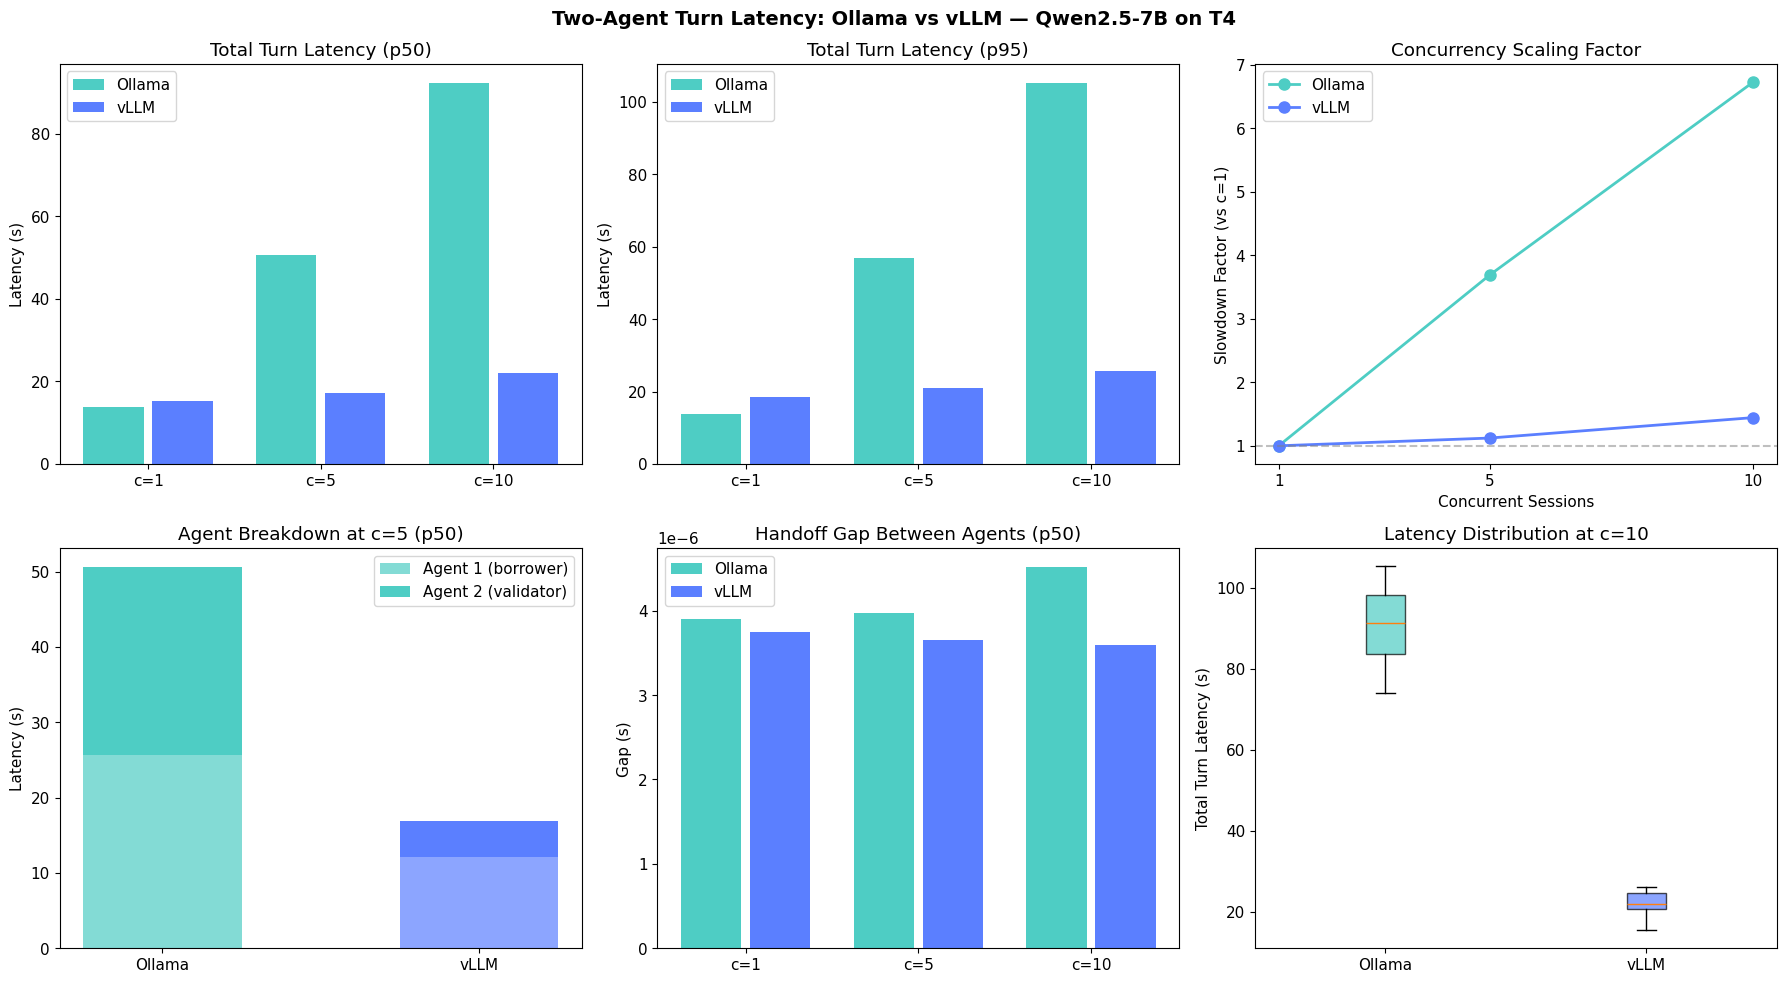

Chart saved to benchmark_results.png


In [29]:
# Cell 11: Charts

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Two-Agent Turn Latency: Ollama vs vLLM — Qwen2.5-7B on T4",
    fontsize=14, fontweight="bold"
)

concurrency_levels = [1, 5, 10]
colors = {"Ollama": "#4ecdc4", "vLLM": "#5b7fff"}

# ---- Plot 1: Total Turn Latency p50 ----
ax = axes[0, 0]
for backend in ["Ollama", "vLLM"]:
    p50s = [all_stats.get((backend, c), {}).get("total_p50", 0) for c in concurrency_levels]
    ax.bar(
        [x + (0.2 if backend == "vLLM" else -0.2) for x in range(3)],
        p50s, width=0.35, label=backend, color=colors[backend]
    )
ax.set_xticks(range(3))
ax.set_xticklabels([f"c={c}" for c in concurrency_levels])
ax.set_ylabel("Latency (s)")
ax.set_title("Total Turn Latency (p50)")
ax.legend()

# ---- Plot 2: Total Turn Latency p95 ----
ax = axes[0, 1]
for backend in ["Ollama", "vLLM"]:
    p95s = [all_stats.get((backend, c), {}).get("total_p95", 0) for c in concurrency_levels]
    ax.bar(
        [x + (0.2 if backend == "vLLM" else -0.2) for x in range(3)],
        p95s, width=0.35, label=backend, color=colors[backend]
    )
ax.set_xticks(range(3))
ax.set_xticklabels([f"c={c}" for c in concurrency_levels])
ax.set_ylabel("Latency (s)")
ax.set_title("Total Turn Latency (p95)")
ax.legend()

# ---- Plot 3: Scaling Factor (normalized to c=1) ----
ax = axes[0, 2]
for backend in ["Ollama", "vLLM"]:
    base = all_stats.get((backend, 1), {}).get("total_p50", 1)
    factors = [
        all_stats.get((backend, c), {}).get("total_p50", base) / base
        for c in concurrency_levels
    ]
    ax.plot(concurrency_levels, factors, "o-", label=backend,
            color=colors[backend], linewidth=2, markersize=8)
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Concurrent Sessions")
ax.set_ylabel("Slowdown Factor (vs c=1)")
ax.set_title("Concurrency Scaling Factor")
ax.legend()
ax.set_xticks(concurrency_levels)

# ---- Plot 4: Agent 1 vs Agent 2 Breakdown at c=5 ----
ax = axes[1, 0]
for backend in ["Ollama", "vLLM"]:
    a1 = all_stats.get((backend, 5), {}).get("a1_p50", 0)
    a2 = all_stats.get((backend, 5), {}).get("a2_p50", 0)
    x_pos = 0 if backend == "Ollama" else 1
    ax.bar(x_pos, a1, width=0.5, label="Agent 1" if x_pos == 0 else "",
           color=colors[backend], alpha=0.7)
    ax.bar(x_pos, a2, bottom=a1, width=0.5,
           label="Agent 2" if x_pos == 0 else "",
           color=colors[backend], alpha=1.0)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Ollama", "vLLM"])
ax.set_ylabel("Latency (s)")
ax.set_title("Agent Breakdown at c=5 (p50)")
ax.legend(["Agent 1 (borrower)", "Agent 2 (validator)"])

# ---- Plot 5: Handoff Gap ----
ax = axes[1, 1]
for backend in ["Ollama", "vLLM"]:
    gaps = [all_stats.get((backend, c), {}).get("gap_p50", 0)
            for c in concurrency_levels]
    ax.bar(
        [x + (0.2 if backend == "vLLM" else -0.2) for x in range(3)],
        gaps, width=0.35, label=backend, color=colors[backend]
    )
ax.set_xticks(range(3))
ax.set_xticklabels([f"c={c}" for c in concurrency_levels])
ax.set_ylabel("Gap (s)")
ax.set_title("Handoff Gap Between Agents (p50)")
ax.legend()

# ---- Plot 6: Latency Distribution Box Plot at c=10 ----
ax = axes[1, 2]
ollama_c10 = [m.total_latency for m in ollama_results.get(10, [])]
vllm_c10 = [m.total_latency for m in vllm_results.get(10, [])]
data = [d for d in [ollama_c10, vllm_c10] if d]
labels = [l for l, d in [("Ollama", ollama_c10), ("vLLM", vllm_c10)] if d]
if data:
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for patch, color in zip(bp["boxes"], [colors.get(l, "gray") for l in labels]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
ax.set_ylabel("Total Turn Latency (s)")
ax.set_title("Latency Distribution at c=10")

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to benchmark_results.png")

In [30]:
# Cell 12: Validator Agent Accuracy — Did the local model
# actually follow the compliance rules + JSON format?

import re

def parse_validation(response: str) -> dict:
    """Try to extract JSON from validator response"""
    # Try direct parse
    try:
        return json.loads(response.strip())
    except:
        pass
    # Try to find JSON in response
    match = re.search(r'\{[^}]+\}', response, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except:
            pass
    return None

print("VALIDATOR AGENT RELIABILITY ANALYSIS")
print("=" * 60)

for backend, results in [("Ollama", ollama_results), ("vLLM", vllm_results)]:
    print(f"\n{backend}:")
    total = 0
    valid_json = 0
    all_pass = 0
    rule_failures = {1: 0, 2: 0, 3: 0}

    for c in [1, 5, 10]:
        for m in results.get(c, []):
            total += 1
            parsed = parse_validation(m.a2_response)
            if parsed:
                valid_json += 1
                if parsed.get("all_pass"):
                    all_pass += 1
                for r in [1, 2, 3]:
                    if not parsed.get(f"rule_{r}_pass", True):
                        rule_failures[r] += 1

    if total:
        print(f"  Total validations: {total}")
        print(f"  Valid JSON output: {valid_json}/{total} ({100*valid_json/total:.0f}%)")
        print(f"  All rules passed: {all_pass}/{valid_json if valid_json else 1}")
        print(f"  Rule failures: R1={rule_failures[1]} R2={rule_failures[2]} R3={rule_failures[3]}")
    else:
        print(f"  No results")

print("\n--- This tells us about local model instruction-following ---")
print("If JSON parse rate is low, the 7B model struggles with structured output.")
print("This is a real production limitation for agent validation layers.")

VALIDATOR AGENT RELIABILITY ANALYSIS

Ollama:
  Total validations: 48
  Valid JSON output: 48/48 (100%)
  All rules passed: 25/48
  Rule failures: R1=23 R2=0 R3=0

vLLM:
  Total validations: 48
  Valid JSON output: 48/48 (100%)
  All rules passed: 33/48
  Rule failures: R1=11 R2=2 R3=4

--- This tells us about local model instruction-following ---
If JSON parse rate is low, the 7B model struggles with structured output.
This is a real production limitation for agent validation layers.


In [31]:
# Cell 13: Save All Raw Data

import json

def metrics_to_dict(m: TurnMetrics) -> dict:
    return {
        "session_id": m.session_id,
        "concurrency": m.concurrency,
        "backend": m.backend,
        "query": m.query[:80],
        "a1_latency": round(m.a1_latency, 3),
        "a1_ttft": round(m.a1_ttft, 3),
        "a2_latency": round(m.a2_latency, 3),
        "a2_ttft": round(m.a2_ttft, 3),
        "handoff_gap": round(m.handoff_gap, 4),
        "total_latency": round(m.total_latency, 3),
        "a1_response": m.a1_response[:200],
        "a2_response": m.a2_response[:200],
        "error": m.error
    }

raw_data = {
    "ollama": {str(c): [metrics_to_dict(m) for m in ms]
               for c, ms in ollama_results.items()},
    "vllm": {str(c): [metrics_to_dict(m) for m in ms]
             for c, ms in vllm_results.items()},
    "summary": {
        f"{b}_c{c}": all_stats.get((b, c), {})
        for b in ["Ollama", "vLLM"] for c in [1, 5, 10]
    }
}

with open("raw_results.json", "w") as f:
    json.dump(raw_data, f, indent=2)

print("Raw results saved to raw_results.json")
print(f"Total data points: {sum(len(ms) for ms in ollama_results.values()) + sum(len(ms) for ms in vllm_results.values())}")

Raw results saved to raw_results.json
Total data points: 96
